### 🗣️ 🕹️ “Chat 형식으로” 미리 학습된 걸 생성함(변신 모델에 기반하여)

#### 🕹️ 트렌스포머 모델 구조

#### 🗣️ chat GPT 1 모델 구조

#### Transformer decoder vs GPT

####

| | Transformer Decoder | GPT (Decoder-only) |
|---|---|---|
| Self-Attention | Masked Multi-Head Self-Attention | 동일 |
| Cross-Attention | **있음** (Encoder 출력을 K,V로 사용) | **없음** |
| Encoder | 필요함 (번역 등 입력 문장 처리용) | 없음 |
| Sub-layer 개수 | 3개 (Self-Attn, Cross-Attn, FFN) | 2개 (Self-Attn, FFN) |
| Add & Norm 위치 | Post-LN (원 논문 기준) | GPT-1은 Post-LN, GPT-2부터 Pre-LN |
| 용도 | 번역처럼 "입력→출력" 변환 작업 | 순수 텍스트 생성 (다음 토큰 예측) |



#### 🗣️🤖 Chatbot 만들어보기

#### 1. 파일 불러오기

In [8]:
import pandas as pd

DATA_PATH = "ChatbotData.csv" # 파일 불러오기

df = pd.read_csv(DATA_PATH)

print("전체 행 개수:", len(df))
print("컬럼 목록:", list(df.columns))
df.head()

전체 행 개수: 11823
컬럼 목록: ['Q', 'A', 'label']


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


---

#### 2. 학습 전 전처리

##### BPE 학습 전 중복대화쌍 삭제 -> SentencePiece 학습용 코퍼스 파일 만들기 -> BPE 토크나이저 학습

In [14]:
pairs = list(zip(df['Q'].astype(str), df['A'].astype(str)))
print("추출된 대화 쌍 개수:", len(pairs))
print("샘플:", pairs[0])

def simple_clean_pairs(pairs, min_chars=1, max_chars=100):
    """
    [BPE 전 1차 정제]
    아직 토크나이저(BPE)가 없는 상태라 '토큰 개수' 기준으로는 거를 수 없음
    → 대신 글자 수 기준으로 1차로만 거름
    → 정확한 토큰 길이 기준 필터링은 BPE 학습 완료 후 다시 수행 가능
    """
    seen = set()       # 중복 제거용 (Q, A) 쌍 집합
    cleaned = []

    for q, a in pairs:
        key = (q, a)
        if key in seen:
            continue    # 이미 나온 쌍이면 스킵 (중복 제거)

        # 너무 짧거나(빈 문장 등) 너무 긴 문장은 제외
        if not (min_chars <= len(q) <= max_chars and min_chars <= len(a) <= max_chars):
            continue

        seen.add(key)
        cleaned.append((q, a))

    return cleaned


# 실제 정제 수행
pairs = simple_clean_pairs(pairs, min_chars=1, max_chars=100)
print("정제 후 대화 쌍 개수:", len(pairs))

추출된 대화 쌍 개수: 11823
샘플: ('12시 땡!', '하루가 또 가네요.')
정제 후 대화 쌍 개수: 11750


In [15]:
# SentencePiece는 파이썬 리스트가 아니라 "한 줄에 문장 하나"인 txt 파일을 입력으로 받음
# (Q, A) 쌍을 한 줄씩 풀어서 별도 파일로 저장해야 함
CORPUS_PATH = "chatbot_corpus.txt"

with open(CORPUS_PATH, "w", encoding="utf-8") as f:
    for q, a in pairs:
        f.write(q.strip() + "\n")   # Query 한 줄
        f.write(a.strip() + "\n")   # Response 한 줄 (Q와 A를 굳이 쌍으로 안 묶고 각각 한 줄씩 씀
                                     #  → BPE는 "단어 조각의 통계"만 학습하면 되므로 순서/쌍 정보는 필요 없음)

print(f"{CORPUS_PATH} 저장 완료, 총 {len(pairs) * 2}줄")

chatbot_corpus.txt 저장 완료, 총 23500줄


In [25]:
!pip install sentencepiece -q

In [26]:
import sentencepiece as spm

# 여러 vocab_size 후보로 BPE를 학습해서 비교
candidates = [2000, 4000, 8000, 16000]
sample_texts = [q for q, a in pairs[:500]]  # 속도를 위해 일부만 샘플링해서 비교용으로 사용

for vs in candidates:
    spm.SentencePieceTrainer.train(
        input=CORPUS_PATH,
        model_prefix=f"test_vocab_{vs}",
        vocab_size=vs,
        model_type="bpe",
        pad_id=0, unk_id=1, bos_id=2, eos_id=3,
        character_coverage=0.9995,
    )
    sp_test = spm.SentencePieceProcessor(model_file=f"test_vocab_{vs}.model")

    avg_tokens = sum(len(sp_test.encode(t)) for t in sample_texts) / len(sample_texts)
    avg_chars = sum(len(t) for t in sample_texts) / len(sample_texts)

import matplotlib.pyplot as plt

print(f"vocab_size={vs:>6} | 평균 글자 수: {avg_chars:.1f} | 평균 토큰 수: {avg_tokens:.1f} | 압축률: {avg_chars/avg_tokens:.2f}")

I0000 00:00:1789371243.153364 3822590 sentencepiece_trainer.cc:105] Starts training with : 
trainer_spec {
  input: chatbot_corpus.txt
  input_format: 
  model_prefix: test_vocab_2000
  model_type: BPE
  vocab_size: 2000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 1
  bos_id: 2
  eos_id: 3
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  e

vocab_size= 16000 | 평균 글자 수: 10.4 | 평균 토큰 수: 3.9 | 압축률: 2.69


I0000 00:00:1789371243.566396 3822590 trainer_interface.cc:714] Saving vocabs: test_vocab_16000.vocab


---

#### 3. 사전 만들기(& vocab 적정 크기 test)

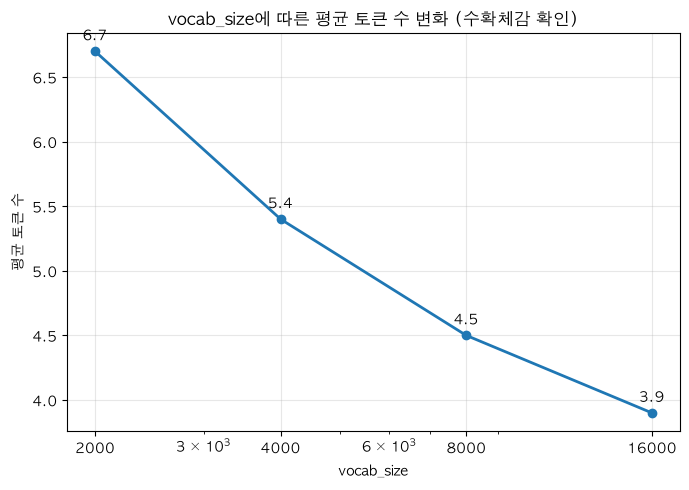

In [27]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'   
plt.rcParams['axes.unicode_minus'] = False    

vocab_sizes = [r["vocab_size"] for r in results]
avg_tokens = [r["평균_토큰_수"] for r in results]

plt.figure(figsize=(7, 5))
plt.plot(vocab_sizes, avg_tokens, marker='o', linewidth=2)

# 각 점 위에 값 표시
for x, y in zip(vocab_sizes, avg_tokens):
    plt.annotate(f"{y}", (x, y), textcoords="offset points", xytext=(0, 8), ha='center')

plt.xlabel("vocab_size")
plt.ylabel("평균 토큰 수")
plt.title("vocab_size에 따른 평균 토큰 수 변화 (수확체감 확인)")
plt.xscale("log")         
plt.xticks(vocab_sizes, [str(v) for v in vocab_sizes])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

| vocab_size | 평균 토큰 수 | 압축률 | 토큰 수 감소폭(직전 대비) |
|---|---|---|---|
| 2,000 | 6.7 | 1.55 | — |
| 4,000 | 5.4 | 1.94 | -1.3 |
| 8,000 | 4.5 | 2.30 | -0.9 |
| 16,000 | 3.9 | 2.69 | -0.6 |

##### 평균 토큰 수 감소폭: vocab을 두 배씩 키울 때마다 이득이 점점 줄음. (-1.3 → -0.9 → -0.6)
##### ->diminishing returns(수확체감) 곡선. 
##### vocab이 큰 게 성능이 비례해서 좋아지는 게 아니라, 어느 지점부터는 vocab만 커지고 실질적인 압축 효과는 점점 미미해짐.
#####
##### 압축 효과: 같은 문장을 표현하는 데 토큰이 몇 개나 필요한가
##### 압축률 = 평균 글자 수 / 평균 토큰 수 압축률이 높다 = 같은 의미를 더 적은 토큰으로 표현한다는 뜻
##### 압축 쪽(vocab ↑): 토큰 수가 줄어서 좋음(6.7 → 5.4 → 4.5 → 3.9)
##### 빈도 쪽(vocab ↑): vocab이 커질수록, 같은 데이터 안에서 토큰 하나당 등장 횟수(=학습 기회)가 줄어듦
#####
##### 현재 상황
##### 압축 이득: 8,000→16,000으로 가면 토큰 수는 겨우 0.6개 더 줄음 (이미 수확체감)
##### 그 대가: 평균 등장 빈도는 13.2회 → 5.7회로 절반 이하로 떨어짐. 각 토큰 Embedding이 학습될 기회가 그만큼 줄어듬.
##### (16,000으로 가는 건 작은 이득(토큰 0.6개 추가 절감)을 위해 큰 대가(빈도 반토막)를 치르는 거라 손해임.

In [28]:
import torch

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("사용 device:", device)

사용 device: mps


In [29]:
import sentencepiece as spm

VOCAB_SIZE = 8000   

spm.SentencePieceTrainer.train(
    input=CORPUS_PATH,        # 코퍼스 파일
    model_prefix="chatbot_bpe",  # 결과물: chatbot_bpe.model, chatbot_bpe.vocab 
    vocab_size=VOCAB_SIZE,
    model_type="bpe",         # Byte-Pair Encoding 방식-서브워드

    # 특수 토큰 ID를 0~3번으로 고정 (나중에 마스킹/패딩 계산할 때 헷갈리지 않도록)
    pad_id=0,   
    unk_id=1,   
    bos_id=2,   
    eos_id=3,  
    
    # Query/Response 경계 표시용 토큰 직접 추가
    user_defined_symbols=["<sep>"],

    character_coverage=0.9995,   # 한글 포함, 데이터에 등장하는 문자의 99.95%를 커버하도록 설정
)

# 학습된 토크나이저 불러오기
sp = spm.SentencePieceProcessor(model_file="chatbot_bpe.model")

# 특수 토큰 ID들을 변수로 미리 빼둠 (뒤에서 시퀀스 만들 때 계속 재사용)
PAD_ID = sp.pad_id()
UNK_ID = sp.unk_id()
BOS_ID = sp.bos_id()
EOS_ID = sp.eos_id()
SEP_ID = sp.piece_to_id("<sep>")   # 직접 추가한 토큰이라 이름으로 ID를 조회해야 함

vocab_size = sp.get_piece_size()   # 이후 모델의 임베딩/출력층 크기로 그대로 사용

print("실제 vocab size:", vocab_size)
print("PAD:", PAD_ID, "UNK:", UNK_ID, "BOS:", BOS_ID, "EOS:", EOS_ID, "SEP:", SEP_ID)

실제 vocab size: 8000
PAD: 0 UNK: 1 BOS: 2 EOS: 3 SEP: 4


I0000 00:00:1789371251.132865 3822590 sentencepiece_trainer.cc:105] Starts training with : 
trainer_spec {
  input: chatbot_corpus.txt
  input_format: 
  model_prefix: chatbot_bpe
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  user_defined_symbols: <sep>
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 1
  bos_id: 2
  eos_id: 3
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <p

---

#### 4. 모델 설계(class 정의)

In [30]:
class GPTDecoderLayer(nn.Module):
    """
    [GPT-1 변경] 기존 DecoderLayer 대비:
      1) enc_dec_attn(Cross-Attention) 서브층을 완전히 제거
         → Encoder가 없으므로 K, V로 사용할 Encoder 출력 자체가 존재하지 않음
      2) norm_1 / norm_2 / norm_3 3개 → norm_1 / norm_2 2개로 축소
      3) LayerNorm 위치를 Pre-LN(서브층 이전 정규화) → Post-LN(서브층 이후 정규화)으로 변경
         (GPT-1 원 논문 Figure 1의 Decoder Block 구조를 그대로 따름)
    """
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(GPTDecoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        """
        x    : 디코더 입력 [batch, seq_len, d_model]
        mask : Causal + Padding 통합 마스크 [batch, 1, seq_len, seq_len]
        """
        # --- Masked Multi-Head Self-Attention ---
        attn_out, attn_weights = self.self_attn(x, x, x, mask)
        attn_out = self.dropout(attn_out)
        x = x + attn_out                  # Residual: 서브층 통과 "전" 값을 더함
        x = self.norm_1(x)                # [GPT-1 변경] LayerNorm이 residual 덧셈 뒤에 옴 (Post-LN)

        # --- Position-Wise Feed Forward Network ---
        ffn_out = self.ffn(x)
        ffn_out = self.dropout(ffn_out)
        x = x + ffn_out                   # Residual
        x = self.norm_2(x)                # [GPT-1 변경] 여기도 FFN 뒤에 정규화 (Post-LN)

        return x, attn_weights


class GPTDecoder(nn.Module):
    """[GPT-1 변경] 기존 Decoder에서 enc_out, dec_enc_mask 인자를 제거
    (Cross-Attention이 없으므로 Encoder 출력 자체가 필요 없음)"""
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(GPTDecoder, self).__init__()
        self.layers = nn.ModuleList([
            GPTDecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])

    def forward(self, x, mask):
        attns = []
        for layer in self.layers:
            x, attn = layer(x, mask)
            attns.append(attn)
        return x, attns

In [32]:
# Token Embedding + Position Embedding + 위 Decoder + 출력층, vocab_size=8000 반영

class GPT1(nn.Module):
    """
    [GPT-1 변경]
      - Encoder 완전 제거 (enc_emb, encoder 필드 없음)
      - Positional Encoding(고정 sin/cos, register_buffer) → Position Embedding(nn.Embedding, 학습됨)으로 교체
      - final_norm 제거: 마지막 블록의 Post-LN이 이미 정규화를 수행하므로 불필요
      - 출력 헤드는 Text Prediction(LM head) 하나만 구성
    """
    def __init__(self, vocab_size, max_len, d_model, n_layers, n_heads, d_ff,
                 dropout=0.1, shared=True):
        super(GPT1, self).__init__()
        self.d_model = d_model

        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)   # [GPT-1 변경] 학습되는 Position Embedding

        # GPT 논문 방식의 초기화 (N(0, 0.02))
        nn.init.normal_(self.token_emb.weight, mean=0.0, std=0.02)
        nn.init.normal_(self.pos_emb.weight, mean=0.0, std=0.02)

        self.dropout = nn.Dropout(dropout)
        self.decoder = GPTDecoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, vocab_size)
        self.shared = shared
        if shared:
            self.fc.weight = self.token_emb.weight   # Token Embedding ↔ 출력층 가중치 공유 (기존과 동일)

    def forward(self, x, mask):
        """
        x    : 토큰 ID 시퀀스 [batch, seq_len]  (BPE로 인코딩된 결과)
        mask : Causal + Padding 통합 마스크
        """
        seq_len = x.size(1)
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0)   # [1, seq_len]

        # [GPT-1 변경] Token Embedding + Position Embedding "더하기" (순서대로 지나가는 게 아님)
        out = self.token_emb(x) + self.pos_emb(positions)
        out = self.dropout(out)

        dec_out, attns = self.decoder(out, mask)
        logits = self.fc(dec_out)          # [GPT-1 변경] final_norm 없이 바로 Linear

        return logits, attns

In [34]:
# 이전에는 Encoder Mask, Enc-Dec Mask, Decoder Mask 3개가 필요했지만 지금은 Causal+padding 하나만 필요
def generate_padding_mask(seq, pad_id=PAD_ID):
    """
    [GPT-1 변경] 기존엔 0을 <PAD>로 하드코딩했지만,
    이제 BPE 토크나이저가 정한 PAD_ID(=0)를 명시적으로 받도록 함
    <PAD> 위치를 1로 표시. [B, L] → [B, 1, 1, L]
    """
    mask = (seq == pad_id).float()
    return mask[:, None, None, :]


def generate_causality_mask(size):
    # 미래 토큰을 1로 표시한 상삼각 행렬. [L, L]
    return torch.triu(torch.ones(size, size), diagonal=1)


def generate_gpt_mask(x, pad_id=PAD_ID): #Cross-Attention용 마스크는 제거됨.
    seq_len = x.shape[1]
    pad_mask = generate_padding_mask(x, pad_id).to(x.device)
    causal_mask = generate_causality_mask(seq_len).to(x.device)
    return torch.max(pad_mask, causal_mask)

In [35]:
test_x = torch.tensor([[BOS_ID, 10, 20, EOS_ID, PAD_ID, PAD_ID]])
test_mask = generate_gpt_mask(test_x)
print(test_mask.shape)   
print(test_mask[0, 0])   # 뒤쪽 <PAD> 열과, 각 행 기준 미래 위치가 1(가려짐)로 나와야 함

torch.Size([1, 1, 6, 6])
tensor([[0., 1., 1., 1., 1., 1.],
        [0., 0., 1., 1., 1., 1.],
        [0., 0., 0., 1., 1., 1.],
        [0., 0., 0., 0., 1., 1.],
        [0., 0., 0., 0., 1., 1.],
        [0., 0., 0., 0., 1., 1.]])


---

#### 5. Dataset/DataLoader  

In [44]:
import numpy as np

# 실제 BPE 인코딩 시 <bos> Q <sep> A <eos> 전체 길이 분포 확인
lengths = []
for q, a in pairs:
    q_ids = sp.encode(q, out_type=int)
    a_ids = sp.encode(a, out_type=int)
    total_len = 1 + len(q_ids) + 1 + len(a_ids) + 1   # bos + Q + sep + A + eos
    lengths.append(total_len)

lengths = np.array(lengths)

print("평균 길이:", lengths.mean())
print("중앙값:", np.median(lengths))
print("최대 길이:", lengths.max())
print("90 퍼센트:", np.percentile(lengths, 90))
print("95 퍼센트:", np.percentile(lengths, 95))
print("99 퍼센트:", np.percentile(lengths, 99))

# MAX_LEN=40으로 잘렸을 때 실제로 얼마나 많은 문장이 잘리는지
cut_ratio = (lengths > 26).mean() * 100
print(f"MAX_LEN=26일 때 잘리는 문장 비율: {cut_ratio:.1f}%")

평균 길이: 14.174893617021276
중앙값: 14.0
최대 길이: 43
90 퍼센트: 19.0
95 퍼센트: 21.0
99 퍼센트: 25.51000000000022
MAX_LEN=26일 때 잘리는 문장 비율: 0.7%


In [40]:
MAX_LEN = 26

def build_sequence(q, a, sp, max_len=MAX_LEN):
    q_ids = sp.encode(q, out_type=int)
    a_ids = sp.encode(a, out_type=int)
    seq = [BOS_ID] + q_ids + [SEP_ID] + a_ids + [EOS_ID]
    seq = seq[:max_len]
    seq = seq + [PAD_ID] * (max_len - len(seq))
    return seq


class ChatbotPretrainDataset(torch.utils.data.Dataset):
    def __init__(self, pairs, sp, max_len=MAX_LEN):
        self.data = [build_sequence(q, a, sp, max_len) for q, a in pairs]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        seq = self.data[idx]
        x = torch.tensor(seq[:-1], dtype=torch.long)
        y = torch.tensor(seq[1:], dtype=torch.long)
        return x, y


import random
random.seed(42)

shuffled_pairs = pairs.copy()
random.shuffle(shuffled_pairs)

val_ratio = 0.1
n_val = max(1, int(len(shuffled_pairs) * val_ratio))
val_pairs = shuffled_pairs[:n_val]
train_pairs = shuffled_pairs[n_val:]

print(f"train pairs: {len(train_pairs)} / val pairs: {len(val_pairs)}")


from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataset = ChatbotPretrainDataset(train_pairs, sp, MAX_LEN)
val_dataset = ChatbotPretrainDataset(val_pairs, sp, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

sample_x, sample_y = next(iter(train_loader))
print("input  shape:", sample_x.shape)
print("target shape:", sample_y.shape)

train pairs: 10575 / val pairs: 1175
input  shape: torch.Size([32, 25])
target shape: torch.Size([32, 25])


---

#### 6. 모델 인스턴스 생성

In [45]:
D_MODEL = 256
N_LAYERS = 4
N_HEADS = 4
D_FF = 512
DROPOUT = 0.1

model = GPT1(
    vocab_size=vocab_size,   # 3단계에서 BPE로 확정된 값 (8000대)
    max_len=MAX_LEN,         # 5단계에서 확정된 값 (26)
    d_model=D_MODEL,
    n_layers=N_LAYERS,
    n_heads=N_HEADS,
    d_ff=D_FF,
    dropout=DROPOUT,
    shared=True,
).to(device)   # [MPS] 모델 전체를 device로 이동

print(model)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"총 학습 파라미터 수: {n_params:,}")

GPT1(
  (token_emb): Embedding(8000, 256)
  (pos_emb): Embedding(26, 256)
  (dropout): Dropout(p=0.1, inplace=False)
  (decoder): GPTDecoder(
    (layers): ModuleList(
      (0-3): 4 x GPTDecoderLayer(
        (self_attn): MultiHeadAttention(
          (W_q): Linear(in_features=256, out_features=256, bias=True)
          (W_k): Linear(in_features=256, out_features=256, bias=True)
          (W_v): Linear(in_features=256, out_features=256, bias=True)
          (linear): Linear(in_features=256, out_features=256, bias=True)
        )
        (ffn): PoswiseFeedForwardNet(
          (w_1): Linear(in_features=256, out_features=512, bias=True)
          (w_2): Linear(in_features=512, out_features=256, bias=True)
          (relu): ReLU()
        )
        (norm_1): LayerNorm((256,), eps=1e-06, elementwise_affine=True, bias=True)
        (norm_2): LayerNorm((256,), eps=1e-06, elementwise_affine=True, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_

In [46]:
# 5단계에서 만든 sample_x도 device로 옮겨줘야 함 (모델과 데이터가 같은 device에 있어야 함)
sample_x, sample_y = sample_x.to(device), sample_y.to(device)
mask = generate_gpt_mask(sample_x).to(device)

logits, attns = model(sample_x, mask)
print("logits shape:", logits.shape)   
print("model device:", next(model.parameters()).device)

logits shape: torch.Size([32, 25, 8000])
model이 올라간 device: mps:0


---

#### 7. 학습루프 돌리기

In [47]:
def evaluate(model, data_loader, criterion, device):
    # val은역전파 없이 loss만 계산
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for x, y in data_loader:
            x, y = x.to(device), y.to(device)
            mask = generate_gpt_mask(x).to(device)
            logits, _ = model(x, mask)
            loss = criterion(logits.reshape(-1, vocab_size), y.reshape(-1))
            total_loss += loss.item()
    model.train()
    return total_loss / len(data_loader)


optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)   # PAD 위치는 loss 계산에서 제외

EPOCHS = 10
best_val_loss = float("inf")
history = {"train_loss": [], "val_loss": []}

model.train()
for epoch in range(EPOCHS):
    train_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)          # [MPS] 배치를 device로 이동
        mask = generate_gpt_mask(x).to(device)

        logits, _ = model(x, mask)
        loss = criterion(logits.reshape(-1, vocab_size), y.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss = evaluate(model, val_loader, criterion, device)   # [Validation] 매 epoch마다 별도 계산

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    marker = " (best)" if val_loss < best_val_loss else ""
    best_val_loss = min(best_val_loss, val_loss)

    print(f"Epoch {epoch+1:2d}/{EPOCHS} - train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f}{marker}")

Epoch  1/10 - train_loss: 6.4393 | val_loss: 5.8949 (best)
Epoch  2/10 - train_loss: 5.6406 | val_loss: 5.5143 (best)
Epoch  3/10 - train_loss: 5.1393 | val_loss: 5.1916 (best)
Epoch  4/10 - train_loss: 4.6839 | val_loss: 4.9728 (best)
Epoch  5/10 - train_loss: 4.2919 | val_loss: 4.8193 (best)
Epoch  6/10 - train_loss: 3.9447 | val_loss: 4.7109 (best)
Epoch  7/10 - train_loss: 3.6360 | val_loss: 4.6642 (best)
Epoch  8/10 - train_loss: 3.3536 | val_loss: 4.6196 (best)
Epoch  9/10 - train_loss: 3.0943 | val_loss: 4.6263
Epoch 10/10 - train_loss: 2.8520 | val_loss: 4.6536


##### - Optimizer: Adam
##### - Loss: Label Smoothing 없음
##### - Scheduler 없음
##### - Checkpoint 저장 안함
##### → 결과: Epoch 8부터 val_loss가 다시 올라감 (과적합 시작)

####

In [49]:
# 모델 재설계 후 다시 루프 돌리기 
import copy
import math

def evaluate(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for x, y in data_loader:
            x, y = x.to(device), y.to(device)
            mask = generate_gpt_mask(x).to(device)
            logits, _ = model(x, mask)
            loss = criterion(logits.reshape(-1, vocab_size), y.reshape(-1))
            total_loss += loss.item()
    model.train()
    return total_loss / len(data_loader)


# --- 모델 생성 (D_MODEL=256, N_LAYERS=4, N_HEADS=4 확정) ---
model = GPT1(
    vocab_size=vocab_size, max_len=MAX_LEN,
    d_model=D_MODEL, n_layers=N_LAYERS, n_heads=N_HEADS, d_ff=D_FF,
    dropout=0.2,
    shared=True,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID, label_smoothing=0.1)

EPOCHS = 15
total_steps = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * 0.05)

def lr_lambda(step):
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

best_val_loss = float("inf")
best_state_dict = None
history = {"train_loss": [], "val_loss": []}

model.train()
for epoch in range(EPOCHS):
    train_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        mask = generate_gpt_mask(x).to(device)

        logits, _ = model(x, mask)
        loss = criterion(logits.reshape(-1, vocab_size), y.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    marker = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = copy.deepcopy(model.state_dict())
        marker = " (best, 저장됨)"

    print(f"Epoch {epoch+1:2d}/{EPOCHS} - train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f}{marker}")

model.load_state_dict(best_state_dict)
print(f"\n최종적으로 val_loss={best_val_loss:.4f} 시점의 가중치를 불러왔습니다.")

Epoch  1/15 - train_loss: 7.3380 | val_loss: 6.5042 (best, 저장됨)
Epoch  2/15 - train_loss: 6.2803 | val_loss: 6.1436 (best, 저장됨)
Epoch  3/15 - train_loss: 5.9004 | val_loss: 5.8811 (best, 저장됨)
Epoch  4/15 - train_loss: 5.5731 | val_loss: 5.6949 (best, 저장됨)
Epoch  5/15 - train_loss: 5.2960 | val_loss: 5.5673 (best, 저장됨)
Epoch  6/15 - train_loss: 5.0653 | val_loss: 5.4674 (best, 저장됨)
Epoch  7/15 - train_loss: 4.8730 | val_loss: 5.4090 (best, 저장됨)
Epoch  8/15 - train_loss: 4.7104 | val_loss: 5.3696 (best, 저장됨)
Epoch  9/15 - train_loss: 4.5810 | val_loss: 5.3431 (best, 저장됨)
Epoch 10/15 - train_loss: 4.4751 | val_loss: 5.3365 (best, 저장됨)
Epoch 11/15 - train_loss: 4.3946 | val_loss: 5.3248 (best, 저장됨)
Epoch 12/15 - train_loss: 4.3347 | val_loss: 5.3173 (best, 저장됨)
Epoch 13/15 - train_loss: 4.2951 | val_loss: 5.3196
Epoch 14/15 - train_loss: 4.2745 | val_loss: 5.3155 (best, 저장됨)
Epoch 15/15 - train_loss: 4.2619 | val_loss: 5.3155 (best, 저장됨)

최종적으로 val_loss=5.3155 시점의 가중치를 불러왔습니다.


#####   - Optimizer: AdamW (weight decay 추가)-> 가중치가 너무 커지지 않도록 매 스텝마다 살짝씩 깎아내는 기법
#####   - Loss: Label Smoothing 추가
#####   - Scheduler: Warmup + Cosine Decay 추가-> 학습률을 학습 도중에 고정해두지 않고, 시간에 따라 계속 바꿔주는 장치(천천히 워밍업, 살살 시작해 점점 완만하게 줄어듦)
#####   - Gradient Clipping 추가 ->기울기가 너무 커지면, 강제로 상한선을 씌워서 잘라내는 것
#####   - Checkpoint 저장 추가 (best_state_dict)
#####   → 결과: 과적합 훨씬 덜함, Epoch 14~15까지 계속 개선/유지

---

#### 8. 질문 생성하기

In [66]:
# Argmax
@torch.no_grad()
def generate(model, query, sp, device, max_len=MAX_LEN, max_new_tokens=20):
    """
    [GPT-1 변경] word-level vocab 대신 BPE(sp)로 인코딩/디코딩
    입력 query를 받아, <bos> Q <sep> 까지 채운 뒤 한 토큰씩 다음 토큰을 예측해서 이어붙임
    """
    model.eval()

    # 1) 입력을 <bos> Q <sep> 형태로 인코딩 (지금부터 <sep> 다음이 모델이 채워야 할 응답 구간)
    ids = [BOS_ID] + sp.encode(query, out_type=int) + [SEP_ID]

    for _ in range(max_new_tokens):
        # 2) 지금까지의 시퀀스를 모델에 넣음 (MAX_LEN 넘으면 뒤쪽 max_len개만 사용)
        x = torch.tensor(ids[-max_len:], dtype=torch.long, device=device).unsqueeze(0)
        mask = generate_gpt_mask(x).to(device)

        logits, _ = model(x, mask)

        # 3) 맨 마지막 위치의 예측만 사용 (그다음에 올 토큰)
        next_id = logits[0, -1].argmax(dim=-1).item() # vocab_size(8000) 축에서 값이 가장 큰 인덱스를 찾음 1등 토큰의 ID를 뽑는 연산

        if next_id == EOS_ID:   # 4) <eos>가 나오면 생성 중단
            break

        ids.append(next_id)

    model.train()

    # 5) <sep> 이후 부분만 잘라서 응답으로 디코딩
    sep_pos = ids.index(SEP_ID)
    response_ids = ids[sep_pos + 1:]
    return sp.decode(response_ids)


# --- 실제 확인 ---
test_queries = ["오늘 날씨 어때", "너 뭐하고 있어", "고마워"]

for q in test_queries:
    response = generate(model, q, sp, device)
    print(f"입력: {q}")
    print(f"출력: {response}")
    print()

입력: 오늘 날씨 어때
출력: 잘 찾아보세요.

입력: 너 뭐하고 있어
출력: 저도 저도 좋아해요.

입력: 고마워
출력: 더 좋은 사람 만날 거예요.



In [51]:
print("챗봇과 대화해보세요! 종료하려면 'quit' 또는 '종료' 입력")
print("-" * 40)

while True:
    user_input = input("나: ")

    if user_input.strip().lower() in ["quit", "exit", "종료"]:
        print("대화를 종료합니다.")
        break

    if not user_input.strip():   # 빈 입력은 그냥 다시 물어봄
        continue 

    response = generate(model, user_input, sp, device)
    print(f"챗봇: {response}")
    print()

챗봇과 대화해보세요! 종료하려면 'quit' 또는 '종료' 입력
----------------------------------------


나:  안녕


챗봇: 힘내세요.



나:  나 오늘 좀 피곤해


챗봇: 잘 찾아보세요.



...

챗봇: 저도 좋아해요.



나:  동어 반복이라는 말을 너가 모를 수도 있겠구나


챗봇: 그런 사람 만날 수 있는 시간이겠네요.



나:  quit


대화를 종료합니다.


In [52]:
# Generate_sampling
@torch.no_grad()
def generate(model, query, sp, device, max_len=MAX_LEN, max_new_tokens=20,
             temperature=0.8, top_p=0.9, repetition_penalty=1.3):
    """
        Greedy(argmax) 대신 확률적 샘플링으로 변경
      - temperature: 1보다 작으면 확률 분포를 더 보수적, 크면 더 다양하게
      - top_p: 누적 확률 상위 p%(=0.9) 안의 후보 중에서만 샘플링 (터무니없는 토큰은 배제)
      - repetition_penalty: 이미 나온 토큰의 점수를 깎아서 같은 말 반복 억제
    """
    model.eval()
    ids = [BOS_ID] + sp.encode(query, out_type=int) + [SEP_ID]

    for _ in range(max_new_tokens):
        x = torch.tensor(ids[-max_len:], dtype=torch.long, device=device).unsqueeze(0)
        mask = generate_gpt_mask(x).to(device) # generate sampling

        logits, _ = model(x, mask)
        next_logits = logits[0, -1].clone()   # [vocab_size]

        # Repetition Penalty: 이미 나온 토큰의 logit을 깎음
        for prev_id in set(ids):
            next_logits[prev_id] /= repetition_penalty

        # Temperature 적용
        next_logits = next_logits / temperature
        probs = F.softmax(next_logits, dim=-1)

        # Top-p(nucleus) 필터링: 누적 확률 top_p를 넘는 순간부터는 후보에서 제외
        sorted_probs, sorted_idx = torch.sort(probs, descending=True)
        cumulative = torch.cumsum(sorted_probs, dim=-1)
        cutoff = (cumulative > top_p).nonzero(as_tuple=True)[0]
        if len(cutoff) > 0:
            sorted_probs[cutoff[0] + 1:] = 0.0
        sorted_probs /= sorted_probs.sum()   # 남은 확률 재정규화

        # 남은 후보 중에서 확률적으로 하나 샘플링 (argmax가 아님!)
        sampled_idx = torch.multinomial(sorted_probs, 1).item()
        next_id = sorted_idx[sampled_idx].item()

        if next_id == EOS_ID:
            break
        ids.append(next_id)

    model.train()
    sep_pos = ids.index(SEP_ID)
    return sp.decode(ids[sep_pos + 1:])

챗봇과 대화해보세요! 종료하려면 'quit' 또는 '종료' 입력
----------------------------------------


나:  안녕


챗봇: 시간이 필요한가봐요.



나:  딴 소리 좀 하지마


챗봇: 공명한 자격증일 거예요.



...

챗봇: 그런 사람이 있을 수도 있어요.



나:  1+1은 뭐야?


챗봇: 그 기간을 기다리고 있나봐요.



나:  quit


대화를 종료합니다.


##### 

### Argmax sampling vs Generate sampling

In [55]:
# --- 1) Argmax(Greedy) 버전을 별도 이름으로 다시 만듦  ---
@torch.no_grad()
def generate_greedy(model, query, sp, device, max_len=MAX_LEN, max_new_tokens=20):
    model.eval()
    ids = [BOS_ID] + sp.encode(query, out_type=int) + [SEP_ID]
    for _ in range(max_new_tokens):
        x = torch.tensor(ids[-max_len:], dtype=torch.long, device=device).unsqueeze(0)
        mask = generate_gpt_mask(x).to(device)
        logits, _ = model(x, mask)
        next_id = logits[0, -1].argmax(dim=-1).item()
        if next_id == EOS_ID:
            break
        ids.append(next_id)
    model.train()
    sep_pos = ids.index(SEP_ID)
    return sp.decode(ids[sep_pos + 1:])


# --- 2) Sampling 버전 기존 generate와 동일---
@torch.no_grad()
def generate_sampling(model, query, sp, device, max_len=MAX_LEN, max_new_tokens=20,
                       temperature=0.8, top_p=0.9, repetition_penalty=1.3):
    model.eval()
    ids = [BOS_ID] + sp.encode(query, out_type=int) + [SEP_ID]
    for _ in range(max_new_tokens):
        x = torch.tensor(ids[-max_len:], dtype=torch.long, device=device).unsqueeze(0)
        mask = generate_gpt_mask(x).to(device)
        logits, _ = model(x, mask)
        next_logits = logits[0, -1].clone()
        for prev_id in set(ids):
            next_logits[prev_id] /= repetition_penalty
        next_logits = next_logits / temperature
        probs = F.softmax(next_logits, dim=-1)
        sorted_probs, sorted_idx = torch.sort(probs, descending=True)
        cumulative = torch.cumsum(sorted_probs, dim=-1)
        cutoff = (cumulative > top_p).nonzero(as_tuple=True)[0]
        if len(cutoff) > 0:
            sorted_probs[cutoff[0] + 1:] = 0.0
        sorted_probs /= sorted_probs.sum()
        sampled_idx = torch.multinomial(sorted_probs, 1).item()
        next_id = sorted_idx[sampled_idx].item()
        if next_id == EOS_ID:
            break
        ids.append(next_id)
    model.train()
    sep_pos = ids.index(SEP_ID)
    return sp.decode(ids[sep_pos + 1:])


# --- 3) 비교 실험: 같은 질문을 Greedy, Sampling 각각 3번씩 ---
test_questions = [
    "안녕",
    "심심해",
    "뭘 찾으라는 거야",
    "1+1은 뭐야?",
]

rows = []
for q in test_questions:
    greedy_answers = [generate_greedy(model, q, sp, device) for _ in range(3)]
    sampling_answers = [generate_sampling(model, q, sp, device) for _ in range(3)]

    rows.append({
        "질문": q,
        "Greedy #1": greedy_answers[0],
        "Greedy #2": greedy_answers[1],
        "Greedy #3": greedy_answers[2],
        "Greedy 전부_동일": len(set(greedy_answers)) == 1,   # [추가] 3개가 다 같은지 True/False로 확인

        "Sampling #1": sampling_answers[0],
        "Sampling #2": sampling_answers[1],
        "Sampling #3": sampling_answers[2],
        "Sampling 전부_동일": len(set(sampling_answers)) == 1,
    })

import pandas as pd
df_compare = pd.DataFrame(rows)
df_compare

,질문,Greedy #1,Greedy #2,Greedy #3,Greedy 전부_동일,Sampling #1,Sampling #2,Sampling #3,Sampling 전부_동일
0,안녕,힘내세요.,힘내세요.,힘내세요.,True,할 수 있을 거예요.,처음부터 잘하는 것도 어떨까요.,시간이 쉽지 않죠.,False
1,심심해,조금만 더 버텨보세요.,조금만 더 버텨보세요.,조금만 더 버텨보세요.,True,끝이 못하겠어해도 돼요.,조금만 더 버텨보세요.,연락하지 않는 어플을 삭제해보세요.,False
2,뭘 찾으라는 거야,직접 물어보는 게 좋을 것 같아요.,직접 물어보는 게 좋을 것 같아요.,직접 물어보는 게 좋을 것 같아요.,True,생각했던 시간과 함께하고 더 좋은곳일 거예요.,자신감을 가지세요.,받는 사람은 한일 수도 있어요.,False
3,1+1은 뭐야?,많이 많이 만나보세요.,많이 많이 만나보세요.,많이 많이 만나보세요.,True,나랑 많이 바꾸세요.,좋은 곳으로 속지 마세요.,어느덧개월이라는 시간이 흘렀네요.,False


##### 

In [65]:
# 질문 추가 - 단문 vs 복문
question_category = {
    "배고파": "단문",
    "힘들어": "단문",
    "진짜 졸려": "단문",
    "너는 누구니?": "단문",
    "속이 울렁거리는데 뭘 먹어야 할까?": "복문",
    "친구랑 싸웠는데 어떻게 화해해야 할까?": "복문",
    "지금 서서 10바퀴를 돌면 어떨까?": "복문",
    "기쁜데 슬프기도 해, 왜 이럴까?": "복문",
}

test_questions = list(question_category.keys())

rows = []
for q in test_questions:
    greedy_answers = [generate_greedy(model, q, sp, device) for _ in range(3)]
    sampling_answers = [generate_sampling(model, q, sp, device) for _ in range(3)]

    rows.append({
        "카테고리": question_category[q],   # [추가]
        "질문": q,
        "Greedy #1": greedy_answers[0],
        "Greedy #2": greedy_answers[1],
        "Greedy #3": greedy_answers[2],

        "│": "", 

        "Sampling #1": sampling_answers[0],
        "Sampling #2": sampling_answers[1],
        "Sampling #3": sampling_answers[2],
    })

import pandas as pd
pd.set_option("display.max_colwidth", None)

df_compare = pd.DataFrame(rows)
df_compare

,카테고리,질문,Greedy #1,Greedy #2,Greedy #3,│,Sampling #1,Sampling #2,Sampling #3
0,단문,배고파,드세요.,드세요.,드세요.,,피부관리까지 좋죠!,다음 번 번적인 원인일 수 있으면 피하세요.,쉽지 않지요.
1,단문,힘들어,잘 될 거예요.,잘 될 거예요.,잘 될 거예요.,,많이 긴장했나봐요.,나한테 관심 있는 게 아니라 대화를 나눠보세요.,상처받지 않았으면 좋겠어요.
2,단문,진짜 졸려,힘내세요.,힘내세요.,힘내세요.,,맘고생 많았어요.,잘하는 거 얼른 충전하세요.,푹 쉬세요.
3,단문,너는 누구니?,저는 위로봇입니다.,저는 위로봇입니다.,저는 위로봇입니다.,,좋아요.,고마운 마음을 가져보세요.,영화는 소리가 소리가 나겠네요.
4,복문,속이 울렁거리는데 뭘 먹어야 할까?,직접 물어보는 게 좋을 것 같아요.,직접 물어보는 게 좋을 것 같아요.,직접 물어보는 게 좋을 것 같아요.,,저는 위로해드리는 로봇이에요.,호감이 있을 것 같아요.,그런 건 강림도 잘 맞리죠.
5,복문,친구랑 싸웠는데 어떻게 화해해야 할까?,마음이 허전하겠어요.,마음이 허전하겠어요.,마음이 허전하겠어요.,,많은 생각을 해보세요.,소중한 사람 만나세요.,함께하고 마음을 확인지기 두고 생각해보세요.
6,복문,지금 서서 10바퀴를 돌면 어떨까?,더 많이 많이 지쳤나봐요.,더 많이 많이 지쳤나봐요.,더 많이 많이 지쳤나봐요.,,그래도 해야 하는 게 좋을 거예요.,잘 수 있을 거예요.,한번 참아보세요.
7,복문,"기쁜데 슬프기도 해, 왜 이럴까?",자신을 더 사랑해주세요.,자신을 더 사랑해주세요.,자신을 더 사랑해주세요.,,항상 항상 막히는 것 같아요.,복하기 힘든 건 아닌지 확인해보세요.,아마 그럴 거예요.


#### sampling 방식 비교

| 생성 함수 | 방식 | 현 프로젝트에서 사용 | GPT-1 |
|---|---|---|---|
| **generate_greedy**  | 확률 1등만 무조건 선택 | ✅ | ✅ |
| **generate_sampling**| 확률 분포를 더 뾰족하게/평평하게 조정 (Temperature) | ✅ | ✅ |
| | 누적 확률이 p(예: 90%)를 넘을 때까지만 후보로 남김 (Top-p, Nucleus Sampling) | ✅ | ❌ (Holtzman et al. 2019 — GPT-1보다 늦게 나온 기법) |
| | 이미 나온 토큰의 확률을 인위적으로 낮춤 (Repetition Penalty) | ✅ | ❌ (당시엔 일반적이지 않음) |
| **generate_beam**  | 여러 후보 시퀀스를 동시에 추적하며 최종적으로 가장 점수 높은 경로 선택 | ❌ | 부분적 (일부 파생 연구에서 시도) |